# Домашнее задание №2. Сегментация клиентов

## Как узнать свою аудиторию?
### Построение различных вариантов кластеризации и интерпретация результатов

### Цель работы

Провести сегментацию клиентов немецкого банка и определить,
на какие группы делится аудитория и какими характеристиками
отличаются полученные группы.

В работе будут рассмотрены следующие методы кластеризации:

- K-Means;
- Hierarchical Clustering;
- DBSCAN.

Для визуализации результатов будут использованы методы снижения размерности:

- PCA;
- UMAP;
- t-SNE.

In [109]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

RANDOM_STATE = 42

In [110]:
DATA_PATH = '../data/german_credit_data.csv'

df = pd.read_csv(DATA_PATH)

print('Размер датасета:', df.shape)

df.head()

Размер датасета: (1000, 10)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


# Часть 1. EDA и Preprocessing

На первом этапе изучим структуру данных, пропуски, распределения числовых
и категориальных признаков. Затем подготовим признаки для кластеризации.


In [112]:
unnamed_columns = [
    column for column in df.columns
    if column.lower().startswith('unnamed')
]

print('Найденные технические столбцы:', unnamed_columns)

if unnamed_columns:
    df = df.drop(columns=unnamed_columns)

print('Размер датасета после удаления технических столбцов:')
print(df.shape)

df.head()

Найденные технические столбцы: ['Unnamed: 0']
Размер датасета после удаления технических столбцов:
(1000, 9)


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


In [113]:
print('Размер датасета:')
print(df.shape)

print('\nСтолбцы:')
print(df.columns.tolist())

print('\nТипы данных:')
print(df.dtypes)

print('\nКоличество дубликатов:')
print(df.duplicated().sum())

print('\nКоличество пропущенных значений:')
print(df.isna().sum())

Размер датасета:
(1000, 9)

Столбцы:
['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']

Типы данных:
Age                 int64
Sex                   str
Job                 int64
Housing               str
Saving accounts       str
Checking account      str
Credit amount       int64
Duration            int64
Purpose               str
dtype: object

Количество дубликатов:
0

Количество пропущенных значений:
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64


In [114]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print('Числовые признаки:')
print(numerical_columns)

print('\nКатегориальные признаки:')
print(categorical_columns)

Числовые признаки:
['Age', 'Job', 'Credit amount', 'Duration']

Категориальные признаки:
['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']


In [115]:
for column in categorical_columns + ['Job']:
    print('=' * 60)
    print(f'Признак: {column}')
    print(df[column].value_counts(dropna=False))
    print()

Признак: Sex
Sex
male      690
female    310
Name: count, dtype: int64

Признак: Housing
Housing
own     713
rent    179
free    108
Name: count, dtype: int64

Признак: Saving accounts
Saving accounts
little        603
NaN           183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

Признак: Checking account
Checking account
NaN         394
little      274
moderate    269
rich         63
Name: count, dtype: int64

Признак: Purpose
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64

Признак: Job
Job
2    630
1    200
3    148
0     22
Name: count, dtype: int64



In [116]:
continuous_columns = [
    'Age',
    'Credit amount',
    'Duration'
]

df[continuous_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Credit amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0


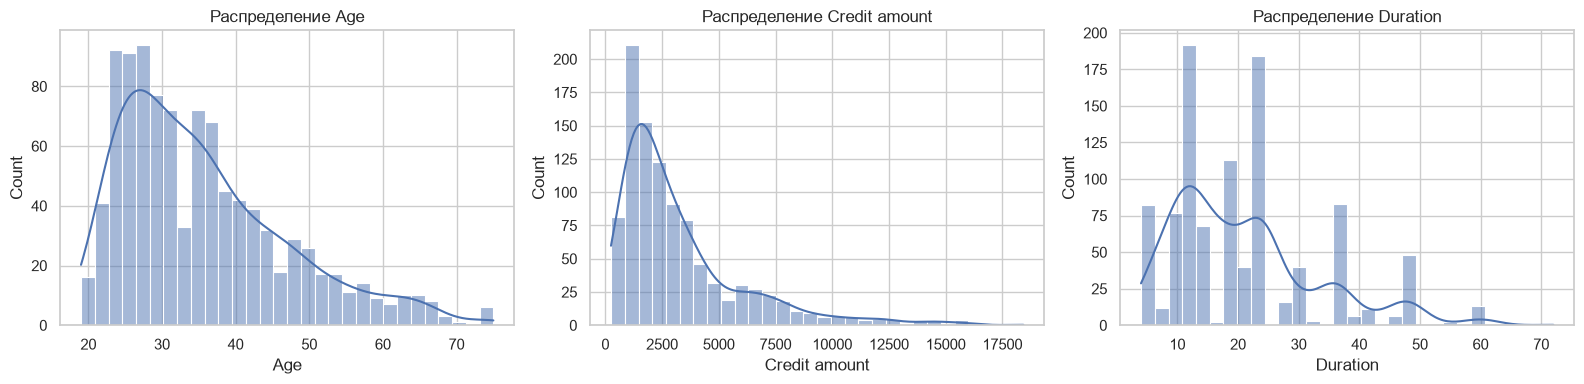

In [117]:
fig, axes = plt.subplots(
    1,
    len(continuous_columns),
    figsize=(16, 4)
)

for ax, column in zip(axes, continuous_columns):
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=30,
        ax=ax
    )

    ax.set_title(f'Распределение {column}')

plt.tight_layout()
plt.show()

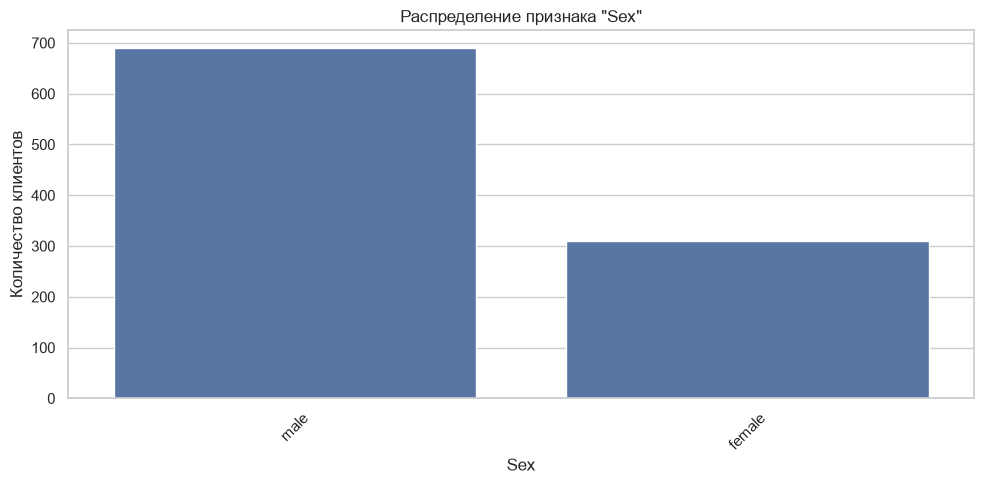

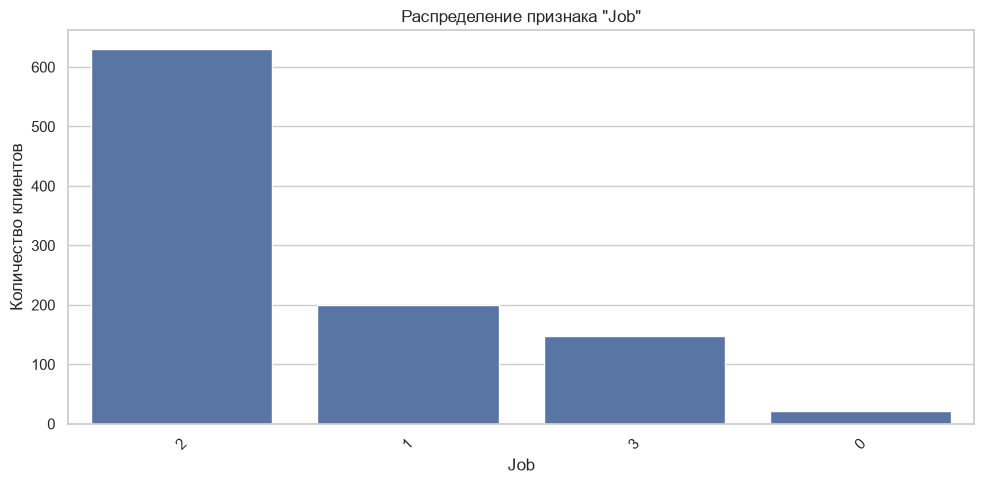

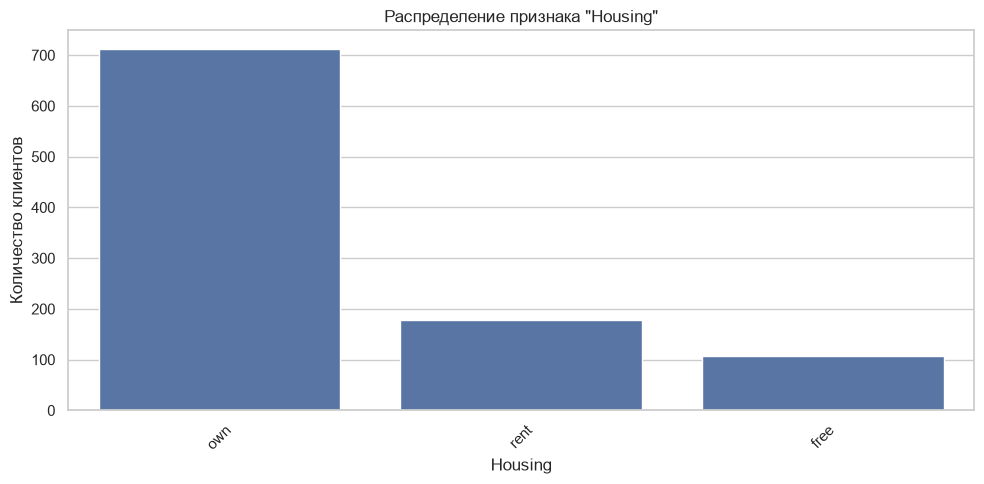

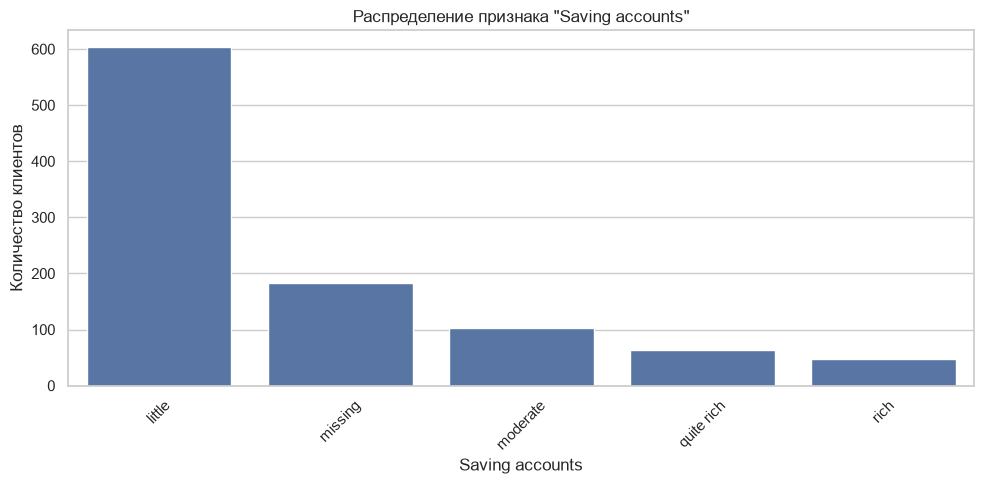

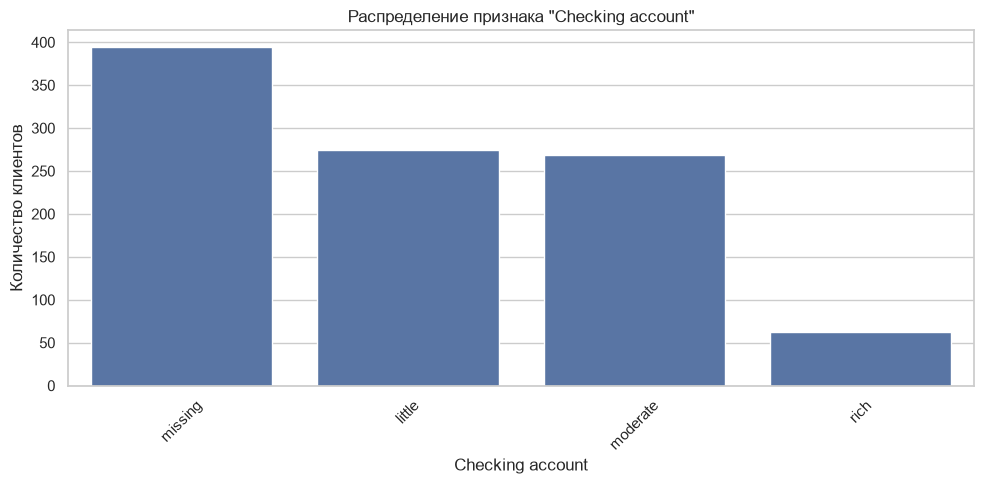

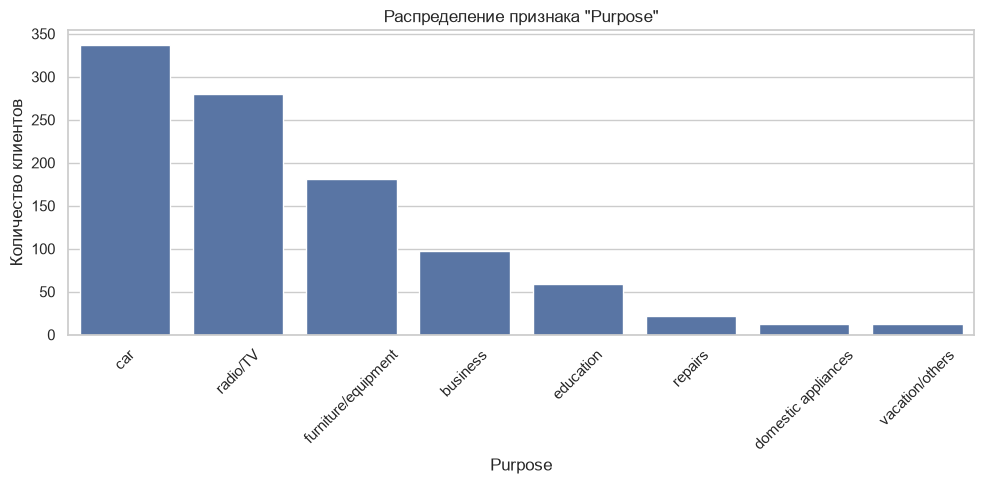

In [118]:
eda_categorical_columns = [
    'Sex',
    'Job',
    'Housing',
    'Saving accounts',
    'Checking account',
    'Purpose'
]

for column in eda_categorical_columns:
    plt.figure(figsize=(10, 5))

    temp = df[column].fillna('missing').astype(str)

    order = temp.value_counts().index

    sns.countplot(
        x=temp,
        order=order
    )

    plt.title(f'Распределение признака "{column}"')
    plt.xlabel(column)
    plt.ylabel('Количество клиентов')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

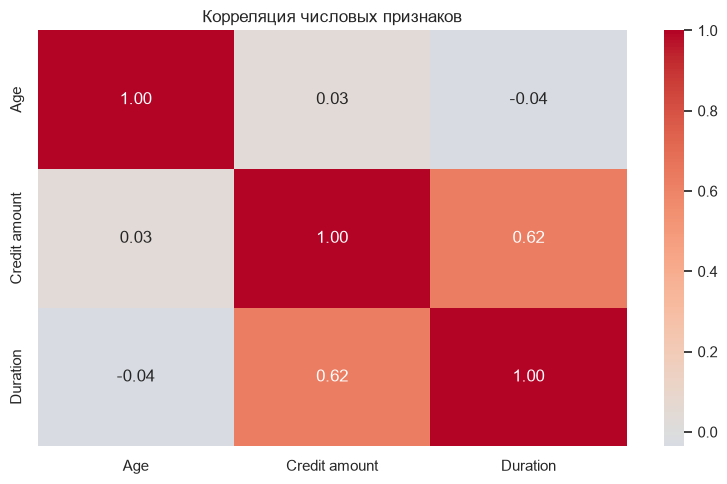

In [119]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    df[continuous_columns].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Корреляция числовых признаков')
plt.tight_layout()
plt.show()

In [120]:
df_preprocessed = df.copy()

df_preprocessed[
    ['Saving accounts', 'Checking account']
] = df_preprocessed[
    ['Saving accounts', 'Checking account']
].fillna('unknown')

print('Количество пропусков после обработки:')
print(df_preprocessed.isna().sum())

Количество пропусков после обработки:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64


In [121]:
numeric_features = [
    'Age',
    'Credit amount',
    'Duration'
]

categorical_features = [
    'Sex',
    'Job',
    'Housing',
    'Saving accounts',
    'Checking account',
    'Purpose'
]

print('Числовые признаки:')
print(numeric_features)

print('\nКатегориальные признаки:')
print(categorical_features)

Числовые признаки:
['Age', 'Credit amount', 'Duration']

Категориальные признаки:
['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']


In [122]:
df_encoded = pd.get_dummies(
    df_preprocessed,
    columns=categorical_features,
    dtype=int
)

print('Размер данных до кодирования:')
print(df_preprocessed.shape)

print('\nРазмер данных после One-Hot Encoding:')
print(df_encoded.shape)

df_encoded.head()

Размер данных до кодирования:
(1000, 9)

Размер данных после One-Hot Encoding:
(1000, 29)


,Age,Credit amount,Duration,Sex_female,Sex_male,Job_0,Job_1,Job_2,Job_3,Housing_free,...,Checking account_rich,Checking account_unknown,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,1169,6,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,22,5951,48,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,49,2096,12,0,1,0,1,0,0,0,...,0,1,0,0,0,1,0,0,0,0
3,45,7882,42,0,1,0,0,1,0,1,...,0,0,0,0,0,0,1,0,0,0
4,53,4870,24,0,1,0,0,1,0,1,...,0,0,0,1,0,0,0,0,0,0


In [123]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_encoded)

print('Размер массива после масштабирования:')
print(X_scaled.shape)

print('\nСреднее первых пяти признаков:')
print(np.round(X_scaled.mean(axis=0)[:5], 3))

print('\nСтандартное отклонение первых пяти признаков:')
print(np.round(X_scaled.std(axis=0)[:5], 3))

Размер массива после масштабирования:
(1000, 29)

Среднее первых пяти признаков:
[ 0.  0.  0. -0.  0.]

Стандартное отклонение первых пяти признаков:
[1. 1. 1. 1. 1.]


In [124]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=df_encoded.columns,
    index=df_encoded.index
)

X_scaled_df.head()

,Age,Credit amount,Duration,Sex_female,Sex_male,Job_0,Job_1,Job_2,Job_3,Housing_free,...,Checking account_rich,Checking account_unknown,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,2.766456,-0.745131,-1.236478,-0.670280,0.670280,-0.149983,-0.5,0.766356,-0.416784,-0.347960,...,-0.259299,-0.806328,-0.327749,-0.712949,-0.110208,-0.250398,-0.470108,1.603567,-0.149983,-0.110208
1,-1.191404,0.949817,2.248194,1.491914,-1.491914,-0.149983,-0.5,0.766356,-0.416784,-0.347960,...,-0.259299,-0.806328,-0.327749,-0.712949,-0.110208,-0.250398,-0.470108,1.603567,-0.149983,-0.110208
2,1.183312,-0.416562,-0.738668,-0.670280,0.670280,-0.149983,2.0,-1.304877,-0.416784,-0.347960,...,-0.259299,1.240190,-0.327749,-0.712949,-0.110208,3.993639,-0.470108,-0.623610,-0.149983,-0.110208
3,0.831502,1.634247,1.750384,-0.670280,0.670280,-0.149983,-0.5,0.766356,-0.416784,2.873893,...,-0.259299,-0.806328,-0.327749,-0.712949,-0.110208,-0.250398,2.127172,-0.623610,-0.149983,-0.110208
4,1.535122,0.566664,0.256953,-0.670280,0.670280,-0.149983,-0.5,0.766356,-0.416784,2.873893,...,-0.259299,-0.806328,-0.327749,1.402626,-0.110208,-0.250398,-0.470108,-0.623610,-0.149983,-0.110208


### Почему необходимо масштабирование?

Алгоритмы K-Means, Hierarchical Clustering и DBSCAN используют расстояния
между объектами. Поэтому признаки должны находиться в сопоставимом масштабе.

Без масштабирования признак `Credit amount`, значения которого измеряются
тысячами, мог бы непропорционально сильно влиять на расстояния по сравнению
с возрастом, сроком кредита и бинарными One-Hot признаками.


# Часть 2. Моделирование

## K-Means

Алгоритм K-Means разбивает объекты на заданное количество кластеров таким образом,
чтобы объекты внутри одного кластера были максимально похожи друг на друга,
а расстояния между различными кластерами были как можно больше.

Для выбора количества кластеров воспользуемся:

- Elbow Method;
- Silhouette Score.

In [125]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 21)

inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

results_kmeans = pd.DataFrame({
    'k': list(k_values),
    'Inertia': inertias,
    'Silhouette Score': silhouette_scores
})

results_kmeans

,k,Inertia,Silhouette Score
0,2,26843.979085,0.097246
1,3,25448.274929,0.094735
2,4,24199.544811,0.098906
3,5,23263.085291,0.115025
4,6,22411.846647,0.110190
5,7,21410.966261,0.111634
6,8,20554.265709,0.106043
7,9,19807.761102,0.104306
8,10,18973.452517,0.116288
9,11,18430.478451,0.123971


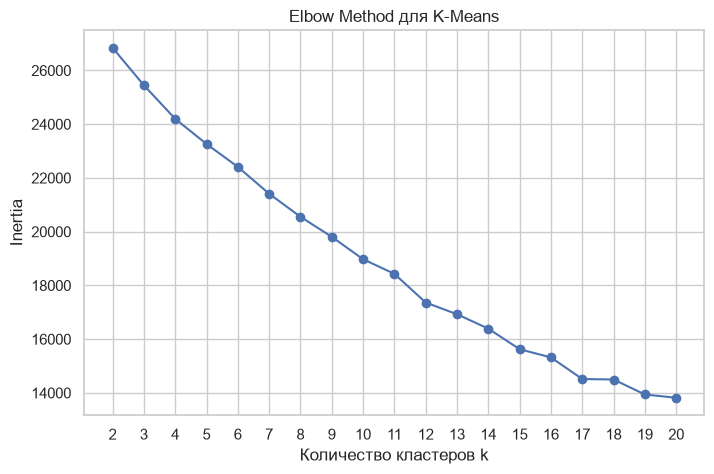

In [126]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    inertias,
    marker='o'
)

plt.title('Elbow Method для K-Means')
plt.xlabel('Количество кластеров k')
plt.ylabel('Inertia')
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

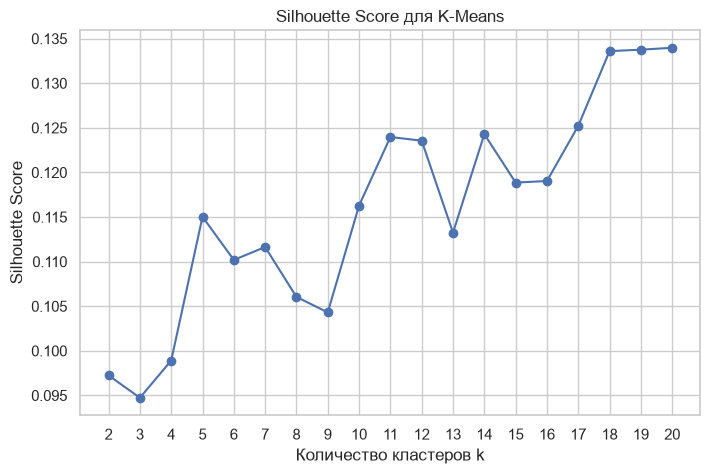

In [127]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker='o'
)

plt.title('Silhouette Score для K-Means')
plt.xlabel('Количество кластеров k')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

In [128]:
best_index = np.argmax(silhouette_scores)

best_k = list(k_values)[best_index]
best_silhouette = silhouette_scores[best_index]

print('Лучшее количество кластеров по Silhouette Score:')
print(best_k)

print('\nЛучший Silhouette Score:')
print(round(best_silhouette, 4))

Лучшее количество кластеров по Silhouette Score:
20

Лучший Silhouette Score:
0.134


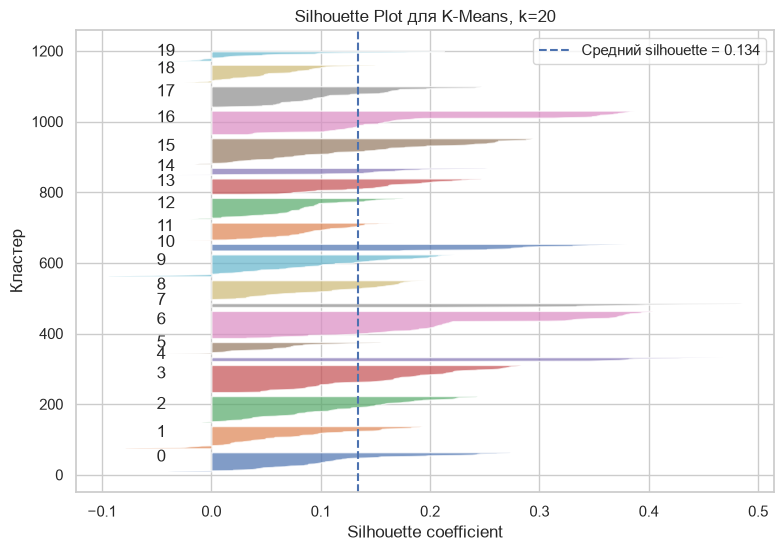

In [129]:
from sklearn.metrics import silhouette_samples

best_kmeans_temp = KMeans(
    n_clusters=best_k,
    random_state=RANDOM_STATE,
    n_init=20
)

best_labels_temp = best_kmeans_temp.fit_predict(X_scaled)

sample_silhouette_values = silhouette_samples(
    X_scaled,
    best_labels_temp
)

fig, ax = plt.subplots(figsize=(9, 6))

y_lower = 10

for cluster_id in range(best_k):
    cluster_values = sample_silhouette_values[
        best_labels_temp == cluster_id
    ]

    cluster_values.sort()

    cluster_size = cluster_values.shape[0]
    y_upper = y_lower + cluster_size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values,
        alpha=0.7
    )

    ax.text(
        -0.05,
        y_lower + 0.5 * cluster_size,
        str(cluster_id)
    )

    y_lower = y_upper + 10

ax.axvline(
    x=best_silhouette,
    linestyle='--',
    label=f'Средний silhouette = {best_silhouette:.3f}'
)

ax.set_title(
    f'Silhouette Plot для K-Means, k={best_k}'
)
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Кластер')
ax.legend()

plt.show()

## Hierarchical Clustering

Иерархическая кластеризация последовательно объединяет наиболее близкие
объекты и группы объектов.

Для оценки структуры кластеров построим дендрограмму, а оптимальное количество
кластеров дополнительно оценим с помощью Silhouette Score.

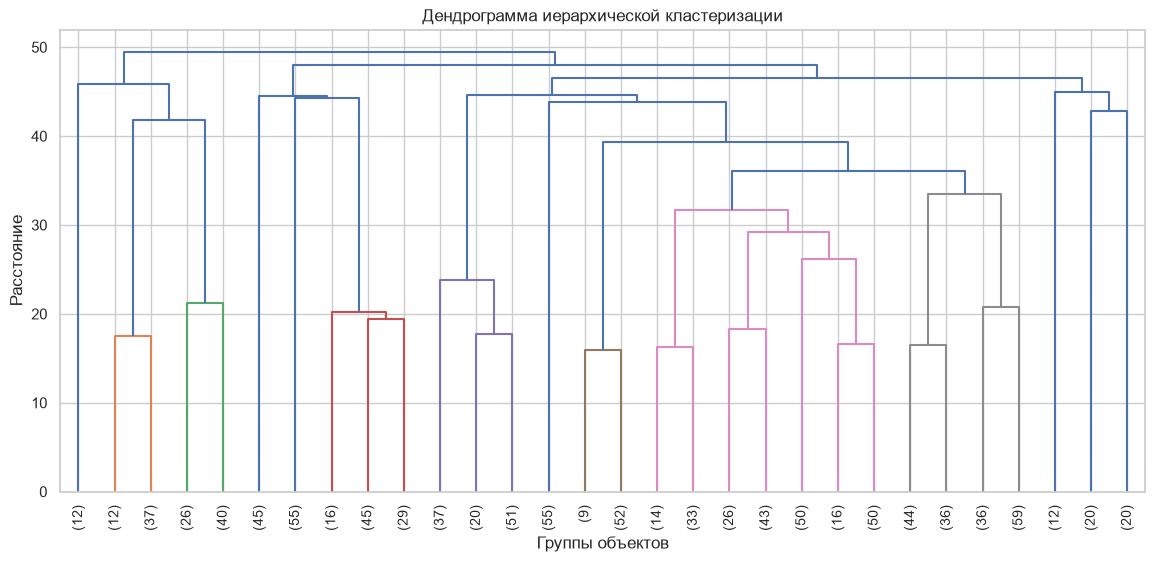

In [130]:
from scipy.cluster.hierarchy import linkage, dendrogram

linkage_matrix = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(14, 6))

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.title('Дендрограмма иерархической кластеризации')
plt.xlabel('Группы объектов')
plt.ylabel('Расстояние')

plt.show()

In [131]:
from sklearn.cluster import AgglomerativeClustering

hierarchical_k_values = range(2, 11)

hierarchical_scores = []

for k in hierarchical_k_values:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='ward'
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    hierarchical_scores.append(score)

hierarchical_results = pd.DataFrame({
    'k': list(hierarchical_k_values),
    'Silhouette Score': hierarchical_scores
})

hierarchical_results

,k,Silhouette Score
0,2,0.128537
1,3,0.091226
2,4,0.101525
3,5,0.107394
4,6,0.116719
5,7,0.074692
6,8,0.092161
7,9,0.109754
8,10,0.123728


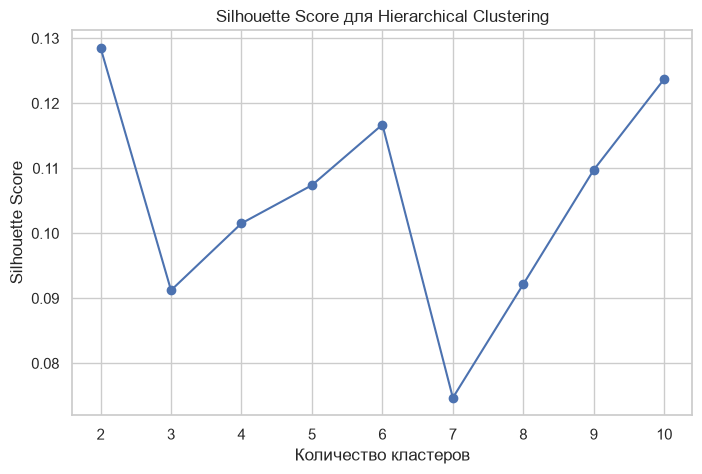

In [132]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(hierarchical_k_values),
    hierarchical_scores,
    marker='o'
)

plt.title('Silhouette Score для Hierarchical Clustering')
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette Score')
plt.xticks(list(hierarchical_k_values))
plt.grid(True)

plt.show()

In [133]:
best_hierarchical_index = np.argmax(
    hierarchical_scores
)

best_hierarchical_k = list(
    hierarchical_k_values
)[best_hierarchical_index]

best_hierarchical_score = hierarchical_scores[
    best_hierarchical_index
]

print(
    'Лучшее количество кластеров:',
    best_hierarchical_k
)

print(
    'Silhouette Score:',
    round(best_hierarchical_score, 4)
)

Лучшее количество кластеров: 2
Silhouette Score: 0.1285


In [134]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=best_hierarchical_k,
    linkage='ward'
)

hierarchical_labels = hierarchical_model.fit_predict(
    X_scaled
)

print('Размеры кластеров:')

print(
    pd.Series(hierarchical_labels)
    .value_counts()
    .sort_index()
)

Размеры кластеров:
0    873
1    127
Name: count, dtype: int64


## DBSCAN

DBSCAN отличается от K-Means и Hierarchical Clustering тем, что количество
кластеров заранее не задаётся.

Алгоритм использует два основных параметра:

- `eps` — максимальное расстояние между соседними объектами;
- `min_samples` — минимальное количество соседних объектов для формирования
  плотной области.

Объекты, которые не относятся ни к одной плотной области, DBSCAN помечает
как шум (`-1`).

Для подбора `eps` используется график расстояний до ближайших соседей
(k-distance plot), являющийся аналогом Elbow Method для DBSCAN.

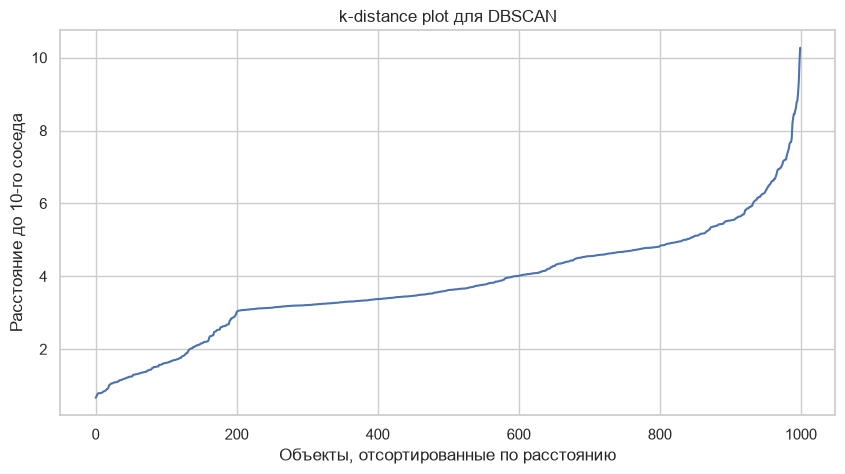

In [135]:
from sklearn.neighbors import NearestNeighbors

min_samples = 10

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors.fit(X_scaled)

distances, indices = neighbors.kneighbors(
    X_scaled
)

k_distances = np.sort(
    distances[:, -1]
)

plt.figure(figsize=(10, 5))

plt.plot(k_distances)

plt.title(
    'k-distance plot для DBSCAN'
)

plt.xlabel(
    'Объекты, отсортированные по расстоянию'
)

plt.ylabel(
    f'Расстояние до {min_samples}-го соседа'
)

plt.grid(True)

plt.show()

In [136]:
from sklearn.cluster import DBSCAN

eps_min = np.quantile(
    k_distances,
    0.70
)

eps_max = np.quantile(
    k_distances,
    0.98
)

eps_values = np.linspace(
    eps_min,
    eps_max,
    20
)

dbscan_results = []

for eps in eps_values:

    model = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = model.fit_predict(
        X_scaled
    )

    clusters = set(labels)

    n_clusters = len(
        clusters - {-1}
    )

    noise_ratio = np.mean(
        labels == -1
    )

    score = np.nan

    non_noise_mask = labels != -1

    if (
        n_clusters >= 2
        and non_noise_mask.sum() > n_clusters
    ):

        score = silhouette_score(
            X_scaled[non_noise_mask],
            labels[non_noise_mask]
        )

    dbscan_results.append({
        'eps': eps,
        'clusters': n_clusters,
        'noise_ratio': noise_ratio,
        'silhouette': score
    })

dbscan_results = pd.DataFrame(
    dbscan_results
)

dbscan_results

,eps,clusters,noise_ratio,silhouette
0,4.550236,5,0.149,0.151852
1,4.690101,4,0.105,0.153666
2,4.829967,3,0.079,0.162865
3,4.969832,3,0.069,0.160545
4,5.109698,3,0.064,0.159218
5,5.249563,2,0.056,0.267136
6,5.389429,2,0.056,0.267136
7,5.529294,2,0.055,0.266854
8,5.669159,2,0.052,0.265981
9,5.809025,2,0.049,0.269350


In [137]:
dbscan_results.sort_values(
    by='silhouette',
    ascending=False
).head(10)

,eps,clusters,noise_ratio,silhouette
19,7.207679,3,0.005,0.374150
18,7.067814,5,0.005,0.280721
15,6.648217,5,0.007,0.280271
17,6.927948,5,0.007,0.280271
16,6.788083,5,0.007,0.280271
14,6.508352,4,0.018,0.277671
13,6.368487,3,0.029,0.275421
12,6.228621,3,0.031,0.274756
9,5.809025,2,0.049,0.269350
10,5.948890,2,0.047,0.268789


In [139]:
valid_dbscan = dbscan_results[
    (dbscan_results['clusters'] >= 2) &
    (dbscan_results['noise_ratio'] <= 0.5) &
    (dbscan_results['silhouette'].notna())
].copy()

if len(valid_dbscan) > 0:
    best_dbscan_row = valid_dbscan.loc[
        valid_dbscan['silhouette'].idxmax()
    ]
else:
    best_dbscan_row = dbscan_results.loc[
        dbscan_results['silhouette'].idxmax()
    ]

best_eps = float(best_dbscan_row['eps'])

print('Выбранный eps:', round(best_eps, 4))
print('Количество кластеров:',
      int(best_dbscan_row['clusters']))
print('Доля шума:',
      round(best_dbscan_row['noise_ratio'], 4))
print('Silhouette:',
      round(best_dbscan_row['silhouette'], 4))

Выбранный eps: 7.2077
Количество кластеров: 3
Доля шума: 0.005
Silhouette: 0.3742


In [140]:
dbscan_model = DBSCAN(
    eps=best_eps,
    min_samples=min_samples
)

dbscan_labels = dbscan_model.fit_predict(
    X_scaled
)

print('Метки DBSCAN и количество объектов:')

print(
    pd.Series(dbscan_labels)
    .value_counts()
    .sort_index()
)

Метки DBSCAN и количество объектов:
-1      5
 0    974
 1     11
 2     10
Name: count, dtype: int64


### Выбор итогового количества кластеров K-Means

При расширении диапазона поиска максимальное значение Silhouette Score было
получено при большом количестве кластеров. Однако дальнейшее увеличение `k`
приводит к дроблению выборки на множество небольших сегментов и существенно
затрудняет интерпретацию результатов.

При `k=5` значение Silhouette Score уже находится на сопоставимом уровне,
а полученные группы остаются достаточно крупными и удобными для анализа.

Поэтому для итоговой клиентской сегментации выбрано 5 кластеров.

In [154]:
FINAL_K = 5

kmeans_model = KMeans(
    n_clusters=FINAL_K,
    random_state=RANDOM_STATE,
    n_init=20
)

kmeans_labels = kmeans_model.fit_predict(X_scaled)

final_kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print('Итоговое количество кластеров K-Means:', FINAL_K)
print(
    'Silhouette Score:',
    round(final_kmeans_score, 4)
)

print('\nРазмеры кластеров:')
print(
    pd.Series(kmeans_labels)
    .value_counts()
    .sort_index()
)

Итоговое количество кластеров K-Means: 5
Silhouette Score: 0.115

Размеры кластеров:
0    106
1    165
2    105
3    451
4    173
Name: count, dtype: int64


## Снижение размерности и визуализация

Для двумерного представления результатов используются PCA, UMAP и t-SNE.
Визуализации ниже строятся уже после выбора итоговой модели K-Means с
пятью кластерами.


In [141]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(
    X_scaled
)

print('Размер после PCA:')
print(X_pca.shape)

print('\nДоля объяснённой дисперсии:')
print(
    np.round(
        pca.explained_variance_ratio_,
        4
    )
)

print(
    '\nСуммарная объяснённая дисперсия:',
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

Размер после PCA:
(1000, 2)

Доля объяснённой дисперсии:
[0.0891 0.0825]

Суммарная объяснённая дисперсия: 0.1716


In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

plots = [
    ('K-Means', kmeans_labels),
    ('Hierarchical', hierarchical_labels),
    ('DBSCAN', dbscan_labels)
]

for ax, (title, labels) in zip(
    axes,
    plots
):
    scatter = ax.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=labels,
        alpha=0.7,
        s=30
    )

    ax.set_title(
        f'PCA — {title}'
    )

    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [ ]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    random_state=RANDOM_STATE
)

X_umap = umap_model.fit_transform(X_scaled)

print('Размер после UMAP:')
print(X_umap.shape)


In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

clustering_results = [
    ('K-Means', kmeans_labels),
    ('Hierarchical', hierarchical_labels),
    ('DBSCAN', dbscan_labels)
]

for ax, (title, labels) in zip(
    axes,
    clustering_results
):
    ax.scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        c=labels,
        alpha=0.7,
        s=30
    )

    ax.set_title(
        f'UMAP — {title}'
    )

    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=RANDOM_STATE,
    init='pca',
    learning_rate='auto'
)

X_tsne = tsne.fit_transform(
    X_scaled
)

print('Размер после t-SNE:')
print(X_tsne.shape)

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for ax, (title, labels) in zip(
    axes,
    clustering_results
):
    ax.scatter(
        X_tsne[:, 0],
        X_tsne[:, 1],
        c=labels,
        alpha=0.7,
        s=30
    )

    ax.set_title(
        f't-SNE — {title}'
    )

    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()

In [ ]:
dbscan_mask = dbscan_labels != -1

if len(set(dbscan_labels[dbscan_mask])) >= 2:
    dbscan_score = silhouette_score(
        X_scaled[dbscan_mask],
        dbscan_labels[dbscan_mask]
    )
else:
    dbscan_score = np.nan

comparison = pd.DataFrame({
    'Метод': [
        'K-Means',
        'Hierarchical',
        'DBSCAN'
    ],
    'Количество кластеров': [
        FINAL_K,
        best_hierarchical_k,
        len(set(dbscan_labels) - {-1})
    ],
    'Silhouette Score': [
        final_kmeans_score,
        best_hierarchical_score,
        dbscan_score
    ]
})

comparison.round(4)


## Сравнение методов кластеризации

Три рассмотренных алгоритма показали различную структуру сегментации.

K-Means при итоговом выборе пяти кластеров получил Silhouette Score около
0.115. Значение является относительно невысоким, поэтому группы клиентов
частично перекрываются и не образуют полностью изолированных областей.

Hierarchical Clustering выделил два основных кластера и получил Silhouette
Score около 0.129. Результат показывает несколько более выраженное разделение,
однако два сегмента дают достаточно грубое представление аудитории.

DBSCAN формально показал наиболее высокий Silhouette Score, однако практически
все наблюдения были объединены в один большой кластер: 974 клиента из 1000.
Два других кластера содержат лишь небольшое число объектов, а часть наблюдений
была отнесена к шуму. Поэтому данный вариант не является удобным для
практической сегментации клиентской базы.

Для дальнейшей интерпретации выбрана модель K-Means с пятью кластерами,
поскольку она обеспечивает более детальное и при этом интерпретируемое
разбиение клиентской аудитории.

# Часть 3. Интерпретация

Для содержательной интерпретации используем K-Means с пятью кластерами.
Рассмотрим размеры сегментов, средние и медианные значения признаков,
boxplot-графики и распределения категориальных признаков.


In [155]:
df_interpret = df_preprocessed.copy()

df_interpret['Cluster'] = kmeans_labels

df_interpret.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Cluster
0,67,male,2,own,unknown,little,1169,6,radio/TV,3
1,22,female,2,own,little,moderate,5951,48,radio/TV,3
2,49,male,1,own,little,unknown,2096,12,education,4
3,45,male,2,free,little,little,7882,42,furniture/equipment,2
4,53,male,2,free,little,little,4870,24,car,2


In [156]:
cluster_sizes = (
    df_interpret['Cluster']
    .value_counts()
    .sort_index()
)

cluster_shares = (
    df_interpret['Cluster']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)

cluster_summary = pd.DataFrame({
    'Количество клиентов': cluster_sizes,
    'Доля, %': cluster_shares
})

cluster_summary

,Количество клиентов,"Доля, %"
Cluster,,
0,106,10.6
1,165,16.5
2,105,10.5
3,451,45.1
4,173,17.3


In [157]:
cluster_means = (
    df_interpret
    .groupby('Cluster')[
        [
            'Age',
            'Credit amount',
            'Duration'
        ]
    ]
    .mean()
    .round(2)
)

cluster_means

,Age,Credit amount,Duration
Cluster,,,
0,37.54,5257.72,25.56
1,29.61,3034.51,18.78
2,43.71,4822.31,27.13
3,34.45,2901.41,21.10
4,37.87,2302.70,15.79


In [163]:
cluster_medians = (
    df_interpret
    .groupby('Cluster')[
        [
            'Age',
            'Credit amount',
            'Duration'
        ]
    ]
    .median()
    .round(2)
)

cluster_medians

,Age,Credit amount,Duration
Cluster,,,
0,35.0,4368.0,24.0
1,26.0,2235.0,15.0
2,42.0,3757.0,24.0
3,32.0,2247.0,18.0
4,37.0,1521.0,12.0


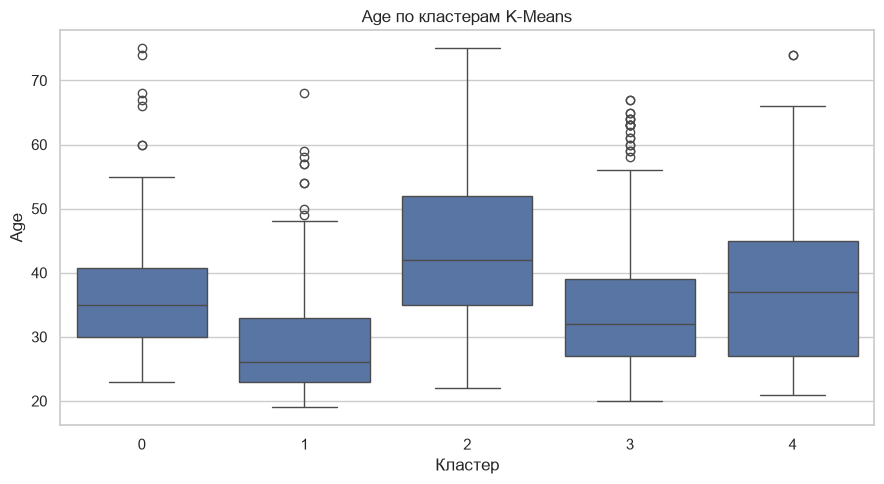

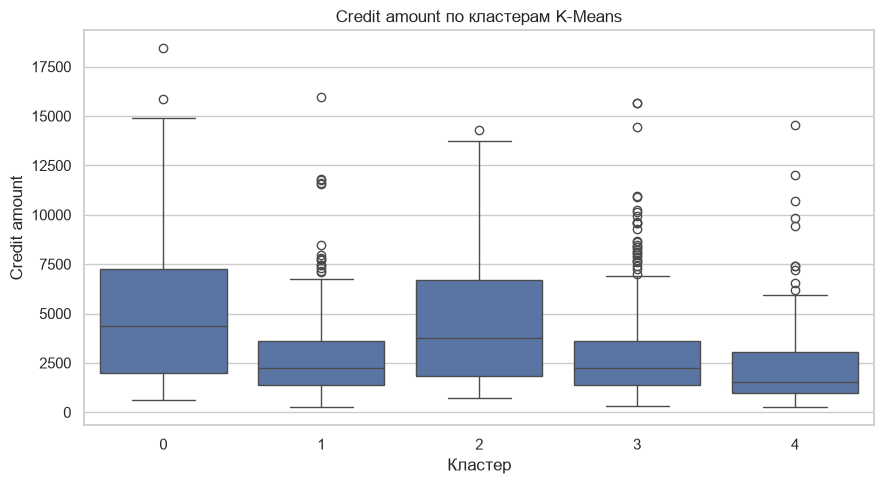

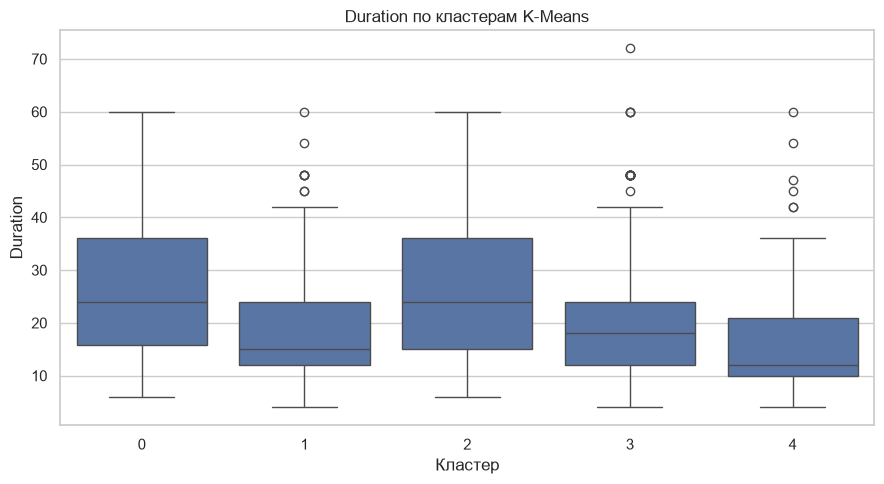

In [158]:
boxplot_columns = [
    'Age',
    'Credit amount',
    'Duration'
]

for column in boxplot_columns:

    plt.figure(figsize=(9, 5))

    sns.boxplot(
        data=df_interpret,
        x='Cluster',
        y=column
    )

    plt.title(
        f'{column} по кластерам K-Means'
    )

    plt.xlabel('Кластер')
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

In [164]:
categorical_columns_for_profile = [
    'Sex',
    'Job',
    'Housing',
    'Saving accounts',
    'Checking account',
    'Purpose'
]

cluster_profiles = []

for cluster_id in sorted(df_interpret['Cluster'].unique()):

    cluster_data = df_interpret[
        df_interpret['Cluster'] == cluster_id
    ]

    profile = {
        'Cluster': cluster_id,
        'Clients': len(cluster_data),
        'Age mean': round(cluster_data['Age'].mean(), 1),
        'Credit mean': round(cluster_data['Credit amount'].mean(), 1),
        'Duration mean': round(cluster_data['Duration'].mean(), 1)
    }

    for column in categorical_columns_for_profile:

        counts = cluster_data[column].value_counts(normalize=True)

        profile[column] = (
            f'{counts.index[0]} '
            f'({counts.iloc[0] * 100:.1f}%)'
        )

    cluster_profiles.append(profile)

cluster_profiles = pd.DataFrame(cluster_profiles)

cluster_profiles

,Cluster,Clients,Age mean,Credit mean,Duration mean,Sex,Job,Housing,Saving accounts,Checking account,Purpose
0,0,106,37.5,5257.7,25.6,male (79.2%),3 (99.1%),own (89.6%),little (57.5%),unknown (42.5%),car (42.5%)
1,1,165,29.6,3034.5,18.8,female (57.6%),2 (69.7%),rent (100.0%),little (60.6%),little (38.8%),car (36.4%)
2,2,105,43.7,4822.3,27.1,male (82.9%),2 (60.0%),free (100.0%),little (62.9%),little (36.2%),car (52.4%)
3,3,451,34.5,2901.4,21.1,male (71.8%),2 (100.0%),own (100.0%),little (58.1%),unknown (45.9%),radio/TV (35.9%)
4,4,173,37.9,2302.7,15.8,male (72.3%),1 (92.5%),own (96.5%),little (65.9%),unknown (32.9%),car (33.5%)


In [165]:
for column in [
    'Sex',
    'Housing',
    'Saving accounts',
    'Checking account',
    'Purpose'
]:
    table = pd.crosstab(
        df_interpret['Cluster'],
        df_interpret[column],
        normalize='index'
    ) * 100

    print('=' * 70)
    print(column)
    print(table.round(1))
    print()

Sex
Sex      female  male
Cluster              
0          20.8  79.2
1          57.6  42.4
2          17.1  82.9
3          28.2  71.8
4          27.7  72.3

Housing
Housing   free    own   rent
Cluster                     
0          2.8   89.6    7.5
1          0.0    0.0  100.0
2        100.0    0.0    0.0
3          0.0  100.0    0.0
4          0.0   96.5    3.5

Saving accounts
Saving accounts  little  moderate  quite rich  rich  unknown
Cluster                                                     
0                  57.5      13.2         5.7   1.9     21.7
1                  60.6      10.9         6.7   5.5     16.4
2                  62.9       7.6         5.7   1.9     21.9
3                  58.1      10.6         6.9   6.0     18.4
4                  65.9       8.7         5.2   4.6     15.6

Checking account
Checking account  little  moderate  rich  unknown
Cluster                                          
0                   16.0      34.0   7.5     42.5
1                 

In [166]:
segment_names = {
    0: 'Крупные кредиты, собственное жильё',
    1: 'Молодые арендаторы',
    2: 'Возрастные клиенты с долгосрочными кредитами',
    3: 'Основной массовый сегмент',
    4: 'Небольшие краткосрочные кредиты'
}

df_interpret['Segment'] = (
    df_interpret['Cluster']
    .map(segment_names)
)

df_interpret[
    [
        'Cluster',
        'Segment',
        'Age',
        'Credit amount',
        'Duration'
    ]
].head()

,Cluster,Segment,Age,Credit amount,Duration
0,3,Основной массовый сегмент,67,1169,6
1,3,Основной массовый сегмент,22,5951,48
2,4,Небольшие краткосрочные кредиты,49,2096,12
3,2,Возрастные клиенты с долгосрочными кредитами,45,7882,42
4,2,Возрастные клиенты с долгосрочными кредитами,53,4870,24


## Интерпретация кластеров K-Means

Для итоговой интерпретации была использована модель K-Means с пятью
кластерами. Такое количество кластеров позволяет получить достаточно
детальную, но при этом интерпретируемую сегментацию клиентской базы.

### Кластер 0 — крупные кредиты, собственное жильё

Кластер содержит 106 клиентов, или 10.6% выборки.

Средний возраст клиентов составляет около 37.5 лет. Средняя сумма кредита
равна 5257.7, а средний срок кредита — 25.6 месяца.

Большинство клиентов — мужчины (79.2%), а 89.6% клиентов имеют собственное
жильё. Наиболее распространённой целью кредита является покупка автомобиля.

Данный сегмент характеризуется относительно крупными и продолжительными
кредитами.

### Кластер 1 — молодые арендаторы

В кластер входит 165 клиентов, или 16.5% выборки.

Это наиболее молодая группа: средний возраст составляет около 29.6 лет.
Средняя сумма кредита — 3034.5, средняя продолжительность — 18.8 месяца.

Все клиенты данного кластера арендуют жильё. В отличие от остальных кластеров,
здесь преобладают женщины — 57.6%.

Данный кластер можно интерпретировать как сегмент относительно молодых
клиентов, не имеющих собственного жилья и использующих кредиты умеренного
размера.

### Кластер 2 — возрастные клиенты с долгосрочными кредитами

Кластер содержит 105 клиентов, или 10.5% выборки.

Средний возраст составляет 43.7 года — это самый высокий показатель среди
полученных сегментов. Средняя сумма кредита достигает 4822.3, а средняя
продолжительность кредита — 27.1 месяца, что также является максимальным
значением среди кластеров.

82.9% клиентов данного сегмента — мужчины. Для всех клиентов признак Housing
имеет значение `free`. Наиболее распространённой целью кредита является
покупка автомобиля.

Таким образом, кластер объединяет более взрослых клиентов с относительно
крупными и наиболее длительными кредитами.

### Кластер 3 — основной массовый сегмент

Это крупнейший кластер: 451 клиент, или 45.1% всей выборки.

Средний возраст составляет 34.5 года, средняя сумма кредита — 2901.4,
а средняя продолжительность — 21.1 месяца.

Все клиенты данного сегмента имеют собственное жильё. Мужчины составляют
71.8% группы. Наиболее распространённой целью кредита является покупка
радио/телевизионной техники.

Этот кластер можно рассматривать как основной массовый сегмент клиентской базы
с кредитами среднего размера и срока.

### Кластер 4 — небольшие краткосрочные кредиты

Кластер включает 173 клиента, или 17.3% выборки.

Средний возраст составляет 37.9 года. Средняя сумма кредита равна 2302.7 —
это минимальное значение среди пяти кластеров. Средняя продолжительность
кредита также минимальна и составляет 15.8 месяца.

Большинство клиентов имеют собственное жильё (96.5%), мужчины составляют
72.3% сегмента.

Данный кластер характеризуется относительно небольшими и краткосрочными
кредитами.

## Анализ различий между кластерами

Наиболее заметные различия между кластерами наблюдаются по следующим
признакам:

### Credit amount

Размер кредита является одним из наиболее важных признаков сегментации.

Кластеры 0 и 2 характеризуются наиболее крупными кредитами, тогда как
кластер 4 отличается минимальной средней суммой кредита.

Также присутствуют отдельные выбросы — клиенты с очень крупными кредитами,
которые значительно превышают типичные значения своих кластеров.

### Duration

Продолжительность кредита также заметно различается между сегментами.

Наиболее длительные кредиты наблюдаются в кластере 2, а наиболее короткие —
в кластере 4. Это согласуется с различиями по размеру кредита: более крупные
кредиты в среднем оформляются на больший срок.

### Age

Возраст также помогает различать отдельные клиентские группы.

Кластер 1 является самым молодым сегментом, тогда как клиенты кластера 2
в среднем заметно старше остальных.

При этом распределения возраста частично пересекаются, поэтому данный признак
сам по себе не позволяет полностью разделить аудиторию.

### Категориальные признаки

Сильные различия наблюдаются по признаку `Housing`.

Кластер 1 полностью состоит из клиентов, арендующих жильё, кластер 2 —
из клиентов со значением `free`, а в кластерах 0, 3 и 4 преимущественно
представлены владельцы собственного жилья.

Также заметны различия по признакам `Job`, `Sex` и `Purpose`.

Признак `Saving accounts` разделяет сегменты слабее: категория `little`
является наиболее распространённой во всех пяти кластерах.

## Визуализация кластеров в двумерном пространстве

Для визуализации многомерных данных были использованы PCA, UMAP и t-SNE.

Первые две компоненты PCA объясняют около 17.16% общей дисперсии данных.
Следовательно, двумерная PCA-проекция сохраняет лишь небольшую часть
информации исходного пространства признаков. Поэтому отсутствие полностью
изолированных кластеров на PCA-графике является ожидаемым результатом.

UMAP и t-SNE позволяют лучше отобразить локальную структуру многомерных
данных и дают дополнительное визуальное представление о взаимном расположении
клиентских групп.

При этом данные не демонстрируют идеально разделённых естественных кластеров:
часть сегментов пересекается, что согласуется с относительно небольшими
значениями Silhouette Score для K-Means и Hierarchical Clustering.

# Итоговые выводы

В ходе работы была выполнена сегментация 1000 клиентов немецкого банка.

На этапе подготовки данных были обработаны пропущенные значения,
категориальные признаки преобразованы с помощью One-Hot Encoding, а все
признаки приведены к единому масштабу с использованием StandardScaler.

Масштабирование особенно важно для используемых алгоритмов кластеризации,
так как они основываются на расстояниях между объектами. Без масштабирования
признаки с большими абсолютными значениями, например `Credit amount`, могли
бы непропорционально сильно влиять на результат.

Были рассмотрены три алгоритма кластеризации:

- K-Means;
- Hierarchical Clustering;
- DBSCAN.

Hierarchical Clustering выделил два основных сегмента и получил Silhouette
Score около 0.129.

DBSCAN показал формально наиболее высокий Silhouette Score — около 0.374.
Однако 974 из 1000 клиентов были объединены в один большой кластер,
а два остальных содержали только 11 и 10 объектов. Ещё 5 клиентов были
определены как шум. Поэтому такое разбиение мало подходит для практической
сегментации клиентской базы.

Для детальной интерпретации была выбрана модель K-Means с пятью кластерами.
Несмотря на относительно невысокий Silhouette Score около 0.115,
она позволяет получить более содержательное разделение аудитории.

Наиболее заметные различия между сегментами связаны с:

- размером кредита;
- продолжительностью кредита;
- возрастом;
- типом жилья;
- видом занятости;
- некоторыми целями кредитования.

В результате удалось выделить следующие клиентские сегменты:

1. клиенты с крупными кредитами и преимущественно собственным жильём;
2. молодые арендаторы;
3. более взрослые клиенты с крупными долгосрочными кредитами;
4. основной массовый сегмент;
5. клиенты с небольшими краткосрочными кредитами.

Таким образом, кластеризация позволяет не только разделить аудиторию
на несколько групп, но и сформировать содержательные профили этих групп,
которые потенциально могут использоваться для персонализации банковских
продуктов и маркетинговых предложений.